# Single-Server Queue

Single server queue (M/M/1) is a fundamental concept in queuing theory, which studies the behavior of waiting lines or queues. In a single-server queue, there is only one server that processes incoming customers or tasks. The key components of a single-server queue include:

- **Arrival Process**: This describes how customers arrive at the queue. It is often modeled using a Poisson process, where arrivals occur randomly over time.
- **Service Process**: This describes how the server processes customers. The service times are often modeled using an exponential distribution, where the time taken to serve each customer is random but has a known average rate.

- **Performance Metrics**: Key performance metrics for a single-server queue include:
  - Average delay in queue (dn)
  - Average number of customers in the queue (ǭn)
  - Proportion of time the server is busy (ມ)

## Event List

In [32]:
# Static Arrival and Service time
# Arrival = [0.4, 1.2, 0.5, 1.7, 0.2, 1.6, 0.2, 1.4, 1.9]
# Service = [2.0, 0.7, 0.2, 1.1, 3.7, 0.6]
# ServiceNum = len(Service)

# Random Arrival and Service time
import random
Arrival = [round(random.uniform(0.1, 2.0), 2) for _ in range(1000)]
Service = [round(random.uniform(0.1, 4.0), 2) for _ in range(1000)]
ServiceNum = len(Service)

## Initialization of States

In [33]:
# System state variables
server_status = 0  # 0 means idle, 1 means busy
number_in_queue = 0
times_of_arrival = []
time_of_last_event = 0.0

clock = 0.0
event_list_arrival = 0.0
event_list_departure = 0.0

# Statistical counters
number_delayed = 0
total_delay = 0.0
area_under_q = 0.0
area_under_b = 0.0

# Plotting variables
queue_times = [] # (time, number_in_queue)
server_status_times = [] # (time, server_status)

## Logic

In [34]:
import math

def handle_arrival():
    global server_status, number_in_queue, total_delay, number_delayed, event_list_departure, clock, area_under_b, area_under_q
    area_under_b += server_status * (clock - time_of_last_event)
    area_under_q += number_in_queue * (clock - time_of_last_event)
    if server_status == 0:
        number_delayed += 1
        server_status = 1
        event_list_departure = clock + Service.pop(0)
    else:
        number_in_queue += 1
        times_of_arrival.append(clock)

def handle_departure():
    global server_status, number_in_queue, total_delay, number_delayed, event_list_arrival, event_list_departure, clock, area_under_b, area_under_q
    area_under_b += server_status * (clock - time_of_last_event)
    area_under_q += number_in_queue * (clock - time_of_last_event)
    if number_in_queue == 0:
        server_status = 0
        event_list_departure = math.inf
    else:
        number_in_queue -= 1
        delay = clock - times_of_arrival.pop(0)
        total_delay += delay
        number_delayed += 1
        event_list_departure = clock + Service.pop(0)

def event_handler():
    global clock, event_list_arrival, event_list_departure, time_of_last_event, queue_times, server_status_times
    queue_times.append((clock, number_in_queue))
    server_status_times.append((clock, server_status))
    if not event_list_arrival and not event_list_departure:
        event_list_arrival = clock + Arrival.pop(0) if Arrival else 0.0
        time_of_last_event = clock
        clock += event_list_arrival if Arrival else 0.0
        return clock
    if event_list_arrival and (not event_list_departure or event_list_arrival <= event_list_departure):
        time_of_last_event = clock
        clock = event_list_arrival
        event_list_arrival = clock + Arrival.pop(0) if Arrival else 0.0
        # Handle arrival event
        handle_arrival()
    else:
        time_of_last_event = clock
        clock = event_list_departure
        # Handle departure event
        handle_departure()
    # queue_times.append((clock, number_in_queue))

iteration = 1
while number_delayed < ServiceNum:
    event_handler()
    
    print("-" * 100)
    print(f"Iteration: {iteration}")
    print("Clock:", clock)
    print("Event List Arrival:", event_list_arrival)
    print("Event List Departure:", event_list_departure)
    print("Server Status:", server_status)
    print("Number in Queue:", number_in_queue)
    print("Times of Arrival:", times_of_arrival)
    print("Number Delayed:", number_delayed)
    print("Total Delay:", total_delay)
    print("Area Under Q:", area_under_q)
    print("Area Under B:", area_under_b)
    iteration += 1

----------------------------------------------------------------------------------------------------
Iteration: 1
Clock: 1.94
Event List Arrival: 1.94
Event List Departure: 0.0
Server Status: 0
Number in Queue: 0
Times of Arrival: []
Number Delayed: 0
Total Delay: 0.0
Area Under Q: 0.0
Area Under B: 0.0
----------------------------------------------------------------------------------------------------
Iteration: 2
Clock: 1.94
Event List Arrival: 3.52
Event List Departure: 5.46
Server Status: 1
Number in Queue: 0
Times of Arrival: []
Number Delayed: 1
Total Delay: 0.0
Area Under Q: 0.0
Area Under B: 0.0
----------------------------------------------------------------------------------------------------
Iteration: 3
Clock: 3.52
Event List Arrival: 4.66
Event List Departure: 5.46
Server Status: 1
Number in Queue: 1
Times of Arrival: [3.52]
Number Delayed: 1
Total Delay: 0.0
Area Under Q: 0.0
Area Under B: 1.58
------------------------------------------------------------------------------

## Report

In [35]:
print("Single-server Queueing System Simulation Results")
print("-" * 100)

print("Mean interarrival time:", clock / number_delayed)
print("Mean service time:", abs((clock - total_delay) / number_delayed))
print("Number of Customers:", number_delayed)

print()
print("Average Delay in Queue:", total_delay / number_delayed)
print("Average Number in Queue:", area_under_q / clock)
print("Server Utilization:", area_under_b / clock)
print("Time Simulation Ended:", clock)

Single-server Queueing System Simulation Results
----------------------------------------------------------------------------------------------------
Mean interarrival time: 2.051770000000001
Mean service time: 479.00969999999984
Number of Customers: 1000

Average Delay in Queue: 481.0614699999999
Average Number in Queue: 234.4616940495277
Server Utilization: 0.9990544749167791
Time Simulation Ended: 2051.7700000000013


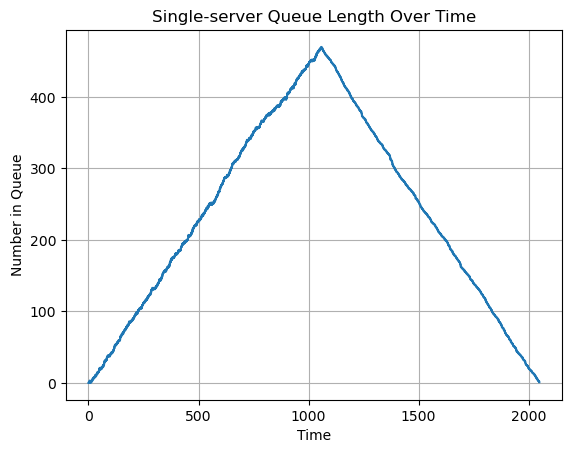

In [36]:
import matplotlib.pyplot as plt

times, queue_lengths = zip(*queue_times)
plt.step(times, queue_lengths, where='post')
plt.xlabel('Time')
plt.ylabel('Number in Queue')
plt.title('Single-server Queue Length Over Time')
plt.grid()

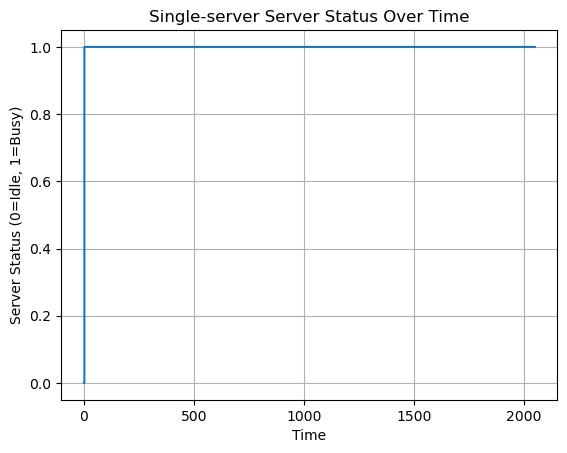

In [37]:
times_b, server_statuses = zip(*server_status_times)
plt.figure()
plt.step(times_b, server_statuses, where='post')
plt.xlabel('Time')
plt.ylabel('Server Status (0=Idle, 1=Busy)')
plt.title('Single-server Server Status Over Time')
plt.grid()